In [1]:
import numpy as np
import glob
import os
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from tqdm import tqdm # Progress bar

In [2]:
# ---- OVERDETERMINED METHOD ----

In [3]:
# ==========================================
# STEP 1: BASIC QUANTUM DEFINITIONS
# ==========================================
# NOTE: In the lab convention, the polarizer passes the state called "V" (vertical).
# In this code, that state corresponds to H = [1,0]^T.
# Labels are swapped relative to lab convention, but the math is consistent.
# Define single-photon basis vectors 
H = np.array([[1], [0]], dtype=complex)
V = np.array([[0], [1]], dtype=complex)
D = (H + V) / np.sqrt(2)
A = (H - V) / np.sqrt(2)
R = (H + 1j * V) / np.sqrt(2)  # Right Circular
L = (H - 1j * V) / np.sqrt(2)  # Left Circular

# Mathematical function to create a projection operator P = |psi><psi|
def projector(ket):
    return ket @ ket.conj().T

# "Catalog" of the 6 possible projectors in our setup
P_base = {
    'H': projector(H), 'V': projector(V),
    'D': projector(D), 'A': projector(A),
    'R': projector(R), 'L': projector(L)
}

# Standard Pauli Matrices
sigma_0 = np.array([[1, 0], [0, 1]], dtype=complex) # I (Identity)
sigma_1 = np.array([[0, 1], [1, 0]], dtype=complex) # X (Diagonal basis)
sigma_2 = np.array([[0, -1j], [1j, 0]], dtype=complex) # Y (Circular basis)
sigma_3 = np.array([[1, 0], [0, -1]], dtype=complex) # Z (Computational basis)
pauli_matrices = [sigma_0, sigma_1, sigma_2, sigma_3]

# Generate the 16 Gamma_j matrices (Tensor product of Pauli matrices for 2 photons)
Gamma = []
for pauli_photon1 in pauli_matrices:
    for pauli_photon2 in pauli_matrices:
        Gamma.append(np.kron(pauli_photon1, pauli_photon2)) #tensor product(kron)

In [4]:
# ==========================================
# STEP 2: EXPERIMENTAL DATA EXTRACTION
# ==========================================
def process_file(filepath):
    """
    Reads the histogram txt file, finds the coincidence peak, 
    subtracts background noise, and returns the net coincidence counts.
    """
    try:
        data = np.loadtxt(filepath, skiprows=1)
        times = data[:, 0]
        counts = data[:, 1]
        
        # Dynamic search for the peak center
        peak_center = times[np.argmax(counts)]
        
        # Integrate the peak (+/- 500 ps window)
        idx_peak = np.where((times >= peak_center - 500) & (times <= peak_center + 500))[0]
        total_coincidences = np.sum(counts[idx_peak])
        
        # Calculate flat background noise (-6000 to -4000 ps)
        idx_bg = np.where((times >= 3000) & (times <= 4000))[0]
        avg_noise = np.mean(counts[idx_bg])
        
        # Subtract noise to get net counts (ensure it doesn't drop below 0)
        net_counts = total_coincidences - (avg_noise * len(idx_peak))
        return max(0, net_counts)
    except Exception as e:
        print(f"Error reading {filepath}: {e}")
        return 0

In [5]:
# ==========================================
# STEP 3: BUILD SYSTEM AND DESIGN MATRIX (A)
# ==========================================
files = glob.glob("Bidirectional_histogram*.txt") # Selects all the files that start with "Bidirectional_histogram" and end with ".txt"
files.sort() # Sort alphabetically to ensure consistent vector order

n_vector = []
P_k_matrices = [] #projector for each physical measurement
extracted_counts_dict = {}

valid_bases = ['H', 'V', 'D', 'A', 'R', 'L']
processed_count = 0

for file in files:
    # 1. Clean the filename to extract just the two letters
    base_name = os.path.basename(file).replace("Bidirectional_histogram_", "").replace("Bidirectional_histogram.", "").replace(".txt", "").strip().upper()
    
    # 2. Check if we actually got exactly 2 valid letters
    if len(base_name) >= 2:
        photon_1, photon_2 = base_name[0], base_name[1]
        
        # 3. Verify both letters exist in our catalog before proceeding
        if photon_1 in valid_bases and photon_2 in valid_bases:
            
            # Get net coincidences
            net_counts = process_file(file)
            n_vector.append(net_counts)
            
            # Only keep the 2-letter key for the dictionary (e.g., 'HH')
            clean_key = f"{photon_1}{photon_2}"
            extracted_counts_dict[clean_key] = net_counts
            
            # Build the 2-photon projector
            P_k = np.kron(P_base[photon_1], P_base[photon_2])
            P_k_matrices.append(P_k)
            
            processed_count += 1
        else:
            print(f"Skipping file (Invalid bases '{photon_1}' or '{photon_2}'): {file}")
    else:
        print(f"Skipping file (Name too short): {file}")

if processed_count != 36:
    print(f"\nCRITICAL WARNING: Processed {processed_count} valid files instead of 36.")
    print("The Moore-Penrose pseudoinverse might fail or give wrong results. Check your folder!")
else:
    print(f"Successfully processed exactly 36 valid measurement files.")

# --- DISPLAY EXTRACTED COUNTS FOR MANUAL VERIFICATION ---
print("\n" + "="*65)
print(" EXPERIMENTAL NET COINCIDENCES (PER STATE)")
print("="*65)
keys = list(extracted_counts_dict.keys())
keys.sort() # Sort alphabetically for display
for i in range(0, len(keys), 4):
    chunk = keys[i:i+4]
    line = "  |  ".join([f"{k}: {extracted_counts_dict[k]:8.1f}" for k in chunk])
    print(line)
print("="*65 + "\n")

n_vector = np.array(n_vector) # Our complete measurement vector


# Build Design Matrix A (rows = processed_count x 16 columns)
A = np.zeros((processed_count, 16), dtype=complex)
for k in range(processed_count):         
    for j in range(16):     
        A[k, j] = np.trace(Gamma[j] @ P_k_matrices[k])

A = np.real(A)

Successfully processed exactly 36 valid measurement files.

 EXPERIMENTAL NET COINCIDENCES (PER STATE)
AA:    764.0  |  AD:    209.0  |  AH:    637.0  |  AL:    212.0
AR:    966.0  |  AV:    617.0  |  DA:    140.0  |  DD:    791.0
DH:    344.0  |  DL:    770.0  |  DR:    113.0  |  DV:    323.0
HA:    878.0  |  HD:     65.0  |  HH:    563.0  |  HL:    806.0
HR:    361.0  |  HV:    650.0  |  LA:    784.0  |  LD:    457.0
LH:    935.0  |  LL:    458.0  |  LR:    505.0  |  LV:    202.0
RA:    521.0  |  RD:    124.0  |  RH:     63.0  |  RL:    461.0
RR:    507.0  |  RV:    968.0  |  VA:    594.0  |  VD:    399.0
VH:    553.0  |  VL:     68.0  |  VR:    997.0  |  VV:    447.0



In [6]:
# ==========================================
# STEP 4: PSEUDOINVERSE AND RECONSTRUCTION
# ==========================================

# Calculate t_opt = (A^T A)^-1 A^T * n using numpy's built-in pinv (Pseudo-INVerse)
t_opt = np.linalg.pinv(A) @ n_vector

# Build the "raw" density matrix using the optimal Stokes parameters
rho_raw = np.zeros((4, 4), dtype=complex)

for j in range(16):
    rho_raw += (t_opt[j] * Gamma[j]) / 4

# Normalize using Method B (forcing Trace = 1) 
rho_matrix = rho_raw / np.trace(rho_raw)

# Calculate the eigenvalues
autovalores = np.linalg.eigvalsh(rho_matrix)

# Density Matrix Puriry
purity = np.trace(rho_matrix @ rho_matrix)

In [7]:
# ==========================================
# STEP 5: DISPLAY RESULTS
# ==========================================

# Configure numpy to avoid messy scientific notation
np.set_printoptions(precision=4, suppress=True, linewidth=120)

print("\n" + "="*65)
print("                       DENSITY MATRIX (\u03C1)")
print("="*65)
print(rho_matrix)
print(f"\nTrace Verification: {np.real(np.trace(rho_matrix)):.4f}")
print(f"\nEigenvalues of the matrix: {autovalores}")
print(f'\nPurity = {np.real(purity):.4f}')


                       DENSITY MATRIX (ρ)
[[ 0.2325+0.j     -0.1434+0.1417j -0.0378+0.2306j  0.1488+0.1826j]
 [-0.1434-0.1417j  0.2893+0.j      0.1485-0.1653j -0.0381-0.1733j]
 [-0.0378-0.2306j  0.1485+0.1653j  0.2583+0.j      0.009 -0.1971j]
 [ 0.1488-0.1826j -0.0381+0.1733j  0.009 +0.1971j  0.2199+0.j    ]]

Trace Verification: 1.0000

Eigenvalues of the matrix: [-0.0779  0.0539  0.151   0.8729]

Purity = 0.7938


In [8]:
# ==========================================
# STEP 6: MAXIMUM LIKELIHOOD ESTIMATION (MLE) + CHOLESKY
# ==========================================

def mle_cost_function(t, n_measured, projectors, N_total):
    """
    Objective function: Builds T, calculates parameterized rho, 
    and returns the Exact Poisson Negative Log-Likelihood.
    """
    # 1. Build lower triangular matrix T (16 real parameters)
    T = np.zeros((4, 4), dtype=complex)
    T[0,0] = t[0]
    T[1,0] = t[4] + 1j*t[5]
    T[1,1] = t[1]
    T[2,0] = t[10] + 1j*t[11]
    T[2,1] = t[6] + 1j*t[7]
    T[2,2] = t[2]
    T[3,0] = t[14] + 1j*t[15]
    T[3,1] = t[12] + 1j*t[13]
    T[3,2] = t[8] + 1j*t[9]
    T[3,3] = t[3]

    # 2. Parameterization (Guarantees Positive Semi-Definite & Trace 1)
    T_dagger = T.conj().T
    rho_trial = (T_dagger @ T) / np.trace(T_dagger @ T)

    # 3. Calculate statistical error (Exact Poisson Log-Likelihood)
    total_error = 0.0
    for k in range(len(n_measured)):
        expected_prob = np.real(np.trace(rho_trial @ projectors[k]))
        n_expected = N_total * expected_prob
        
        # Epsilon critical safety net to prevent np.log(0) -> -inf
        if n_expected < 1e-9:
            n_expected = 1e-9
            
        # Exact Poisson Negative Log-Likelihood: mu - n*ln(mu)
        total_error += n_expected - n_measured[k] * np.log(n_expected)
        
    return total_error


# --- STARTING MLE OPTIMIZATION (EXACT POISSON) ---


# Calculate the total number of photons in a complete basis.
# Assuming indices 0 to 3 of n_vector correspond to HH, HV, VH, VV.
# If your order is different (e.g., alphabetical), you must sum the counts of a complete basis.
N_total = extracted_counts_dict['HH'] + extracted_counts_dict['HV'] + extracted_counts_dict['VH'] + extracted_counts_dict['VV']

# Initial vector t0 (Identity Matrix: t1,t2,t3,t4 = 1, rest = 0)
# This is the standard, unbiased starting point (Maximally Mixed State)
t_initial = np.zeros(16)
t_initial[0:4] = 1.0 

# Optimizer execution (L-BFGS-B algorithm)
opt_result = minimize( # returns the coordinates of the lowest point of a mathematical topology [f(x)]
    mle_cost_function, 
    t_initial, # variable values
    args=(n_vector, P_k_matrices, N_total), # fixed values
    method='L-BFGS-B', # Numerical Algorithm
    options={'maxiter': 5000, 'disp': False} # Boundary Conditions (maxiter=steps)
)

if opt_result.success:
    print("-> MLE Optimization converged successfully.")
else:
    print("-> Warning: The optimizer did not fully converge.")

# ==========================================
# STEP 7: RECONSTRUCTION OF THE OPTIMAL MATRIX
# ==========================================
t_opt = opt_result.x

T_opt = np.zeros((4, 4), dtype=complex)
T_opt[0,0] = t_opt[0]
T_opt[1,0] = t_opt[4] + 1j*t_opt[5]
T_opt[1,1] = t_opt[1]
T_opt[2,0] = t_opt[10] + 1j*t_opt[11]
T_opt[2,1] = t_opt[6] + 1j*t_opt[7]
T_opt[2,2] = t_opt[2]
T_opt[3,0] = t_opt[14] + 1j*t_opt[15]
T_opt[3,1] = t_opt[12] + 1j*t_opt[13]
T_opt[3,2] = t_opt[8] + 1j*t_opt[9]
T_opt[3,3] = t_opt[3]

# Strict final matrix
rho_mle = (T_opt.conj().T @ T_opt) / np.trace(T_opt.conj().T @ T_opt)

#Density Matrix MLE Puriry
purity_mle = np.trace(rho_mle @ rho_mle)

# Display results
np.set_printoptions(precision=4, suppress=True, linewidth=120)
print("\n" + "="*65)
print("      OPTIMAL DENSITY MATRIX (MLE EXACT POISSON + CHOLESKY)")
print("="*65)
print(rho_mle)

print(f"\nFinal Trace: {np.real(np.trace(rho_mle)):.4f}")
print(f"\nMLE Eigenvalues: {np.linalg.eigvalsh(rho_mle)}")
print(f'\nPurity = {np.real(purity_mle):.4f}')

-> MLE Optimization converged successfully.

      OPTIMAL DENSITY MATRIX (MLE EXACT POISSON + CHOLESKY)
[[ 0.2581+0.j     -0.1884+0.1264j -0.0749+0.2142j  0.1641+0.1542j]
 [-0.1884-0.1264j  0.2609+0.j      0.1572-0.1597j -0.0522-0.1528j]
 [-0.0749-0.2142j  0.1572+0.1597j  0.2439+0.j      0.04  -0.1936j]
 [ 0.1641-0.1542j -0.0522+0.1528j  0.04  +0.1936j  0.2371+0.j    ]]

Final Trace: 1.0000

MLE Eigenvalues: [0.     0.01   0.1088 0.8812]

Purity = 0.7885


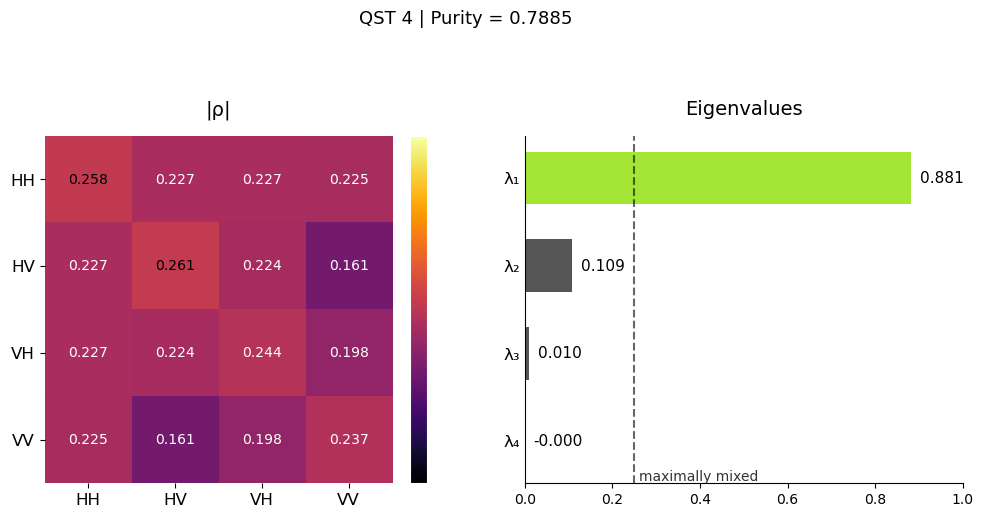

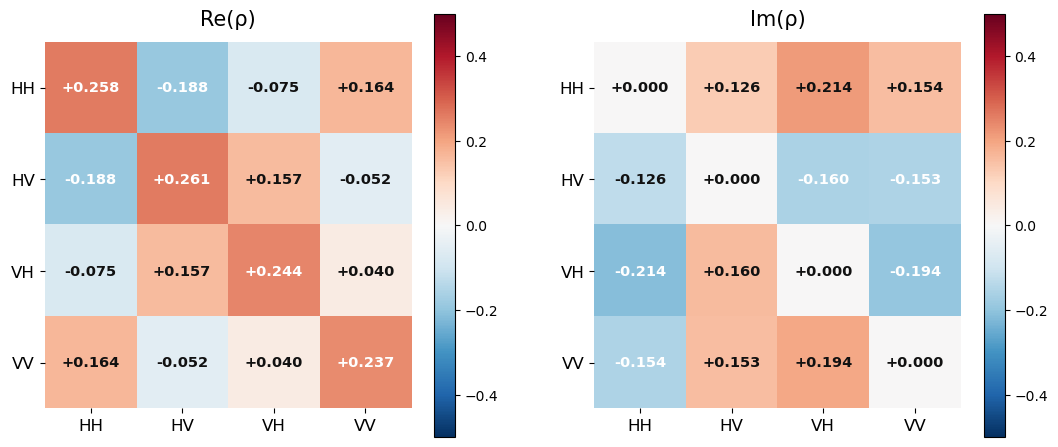

In [9]:
# 1. Define the complex density matrix
rho = np.array([
    [ 0.2581+0.j,  -0.1884+0.1264j, -0.0749+0.2142j,  0.1641+0.1542j],
    [-0.1884-0.1264j,  0.2609+0.j,   0.1572-0.1597j, -0.0522-0.1528j],
    [-0.0749-0.2142j,  0.1572+0.1597j,  0.2439+0.j,   0.04  -0.1936j],
    [ 0.1641-0.1542j, -0.0522+0.1528j,  0.04  +0.1936j,  0.2371+0.j ]
])

color_1 = 'black'
# Compute absolute values and eigenvalues
rho_abs = np.abs(rho)
# Using eigh since density matrices are Hermitian, guarantees real eigenvalues
eigenvalues = np.linalg.eigh(rho)[0] 
eigenvalues = np.sort(eigenvalues)[::-1] # Sort descending

# 2. Figure setup
bg_color = 'white'
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 5.5), facecolor=bg_color)
fig.suptitle("QST 4 | Purity = 0.7885", 
             color=color_1, fontsize=13, y=0.98)

# ==========================================
# LEFT SUBPLOT: Heatmap of Absolute Values
# ==========================================
ax1.set_facecolor(bg_color)

# Plot heatmap
im = ax1.imshow(rho_abs, cmap='inferno', vmin=0, vmax=0.5)

# Axis ticks and labels
labels = ['HH', 'HV', 'VH', 'VV']
ax1.set_xticks(np.arange(4))
ax1.set_yticks(np.arange(4))
ax1.set_xticklabels(labels, fontsize=12)
ax1.set_yticklabels(labels, fontsize=12)
ax1.set_title("|ρ|", color=color_1, fontsize=14, pad=15)

# Remove spines for heatmap
for spine in ax1.spines.values():
    spine.set_visible(False)

# Annotate each cell
for i in range(4):
    for j in range(4):
        val = rho_abs[i, j]
        text_color = 'white' if val < 0.25 else 'black'
        ax1.text(j, i, f"{val:.3f}", ha="center", va="center", color=text_color)

# Add white colorbar
cbar = fig.colorbar(im, ax=ax1, fraction=0.046, pad=0.04)
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='white')
cbar.outline.set_edgecolor('white')

# ==========================================
# RIGHT SUBPLOT: Eigenvalues Bar Chart
# ==========================================
ax2.set_facecolor(bg_color)

y_pos = np.arange(4)
labels_eig = ['λ₁', 'λ₂', 'λ₃', 'λ₄']

# Determine colors for bars (UPDATED: > 0.15 threshold and #555555 base color)
bar_colors = ['#a3e635' if val > 0.25 else '#555555' for val in eigenvalues]

# Plot horizontal bars
bars = ax2.barh(y_pos, eigenvalues, color=bar_colors, height=0.6)

# Axis configuration
ax2.set_yticks(y_pos)
ax2.set_yticklabels(labels_eig, color=color_1, fontsize=12)
ax2.invert_yaxis()  # Highest eigenvalue at the top
ax2.set_xlim(0, 1)
ax2.set_title("Eigenvalues", color=color_1, fontsize=14, pad=15)

# Tick colors and spine styling
ax2.tick_params(axis='x', colors=color_1)
ax2.tick_params(axis='y', colors=color_1, length=0) # Hide y-ticks but keep labels
for spine in ['bottom', 'left']:
    ax2.spines[spine].set_color(color_1)
for spine in ['top', 'right']:
    ax2.spines[spine].set_visible(False)

# Annotate bars with values
for i, val in enumerate(eigenvalues):
    ax2.text(val + 0.02, i, f"{val:.3f}", color=color_1, va='center', fontsize=11)

# Vertical dashed line for maximally mixed state
ax2.axvline(x=0.25, color=color_1, linestyle='--', alpha=0.6)
ax2.text(0.26, 3.4, "maximally mixed", color=color_1, va='center', alpha=0.8, fontsize=10)

# ==========================================
# FINAL ADJUSTMENTS AND EXPORT
# ==========================================
plt.tight_layout(pad=3.0)
plt.savefig('qst4_presentation.png', dpi=180, bbox_inches='tight', facecolor=bg_color)
plt.show()

# ===========================================
# RE & IM PART
# ===========================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5), facecolor=bg_color)

for ax, data, title in zip(axes, [np.real(rho), np.imag(rho)], ['Re(ρ)', 'Im(ρ)']):
    ax.set_facecolor(bg_color)
    im = ax.imshow(data, cmap='RdBu_r', vmin=-0.5, vmax=0.5)
    for i in range(4):
        for j in range(4):
            val = data[i, j]
            norm = (val + 0.5) / 1.0
            color = 'white' if (norm < 0.35 or norm > 0.72) else '#111'
            ax.text(j, i, f'{val:+.3f}', ha='center', va='center',
                    fontsize=10.5, fontweight='bold', color=color)
    ax.set_xticks(range(4)); ax.set_yticks(range(4))
    ax.set_xticklabels(labels, color=color_1, fontsize=12)
    ax.set_yticklabels(labels, color=color_1, fontsize=12)
    ax.set_title(title, color=color_1, fontsize=15, pad=12)
    for spine in ax.spines.values(): spine.set_visible(False)
    cb = plt.colorbar(im, ax=ax, ticks=[-0.4,-0.2,0,0.2,0.4])
    plt.setp(cb.ax.yaxis.get_ticklabels(), color=color_1)

plt.savefig('qst4_re_im.png', dpi=180, bbox_inches='tight', facecolor=bg_color)

### MONTE CARLO ANALYSIS — ANGULAR ERROR PROPAGATION IN QST


Running 500 Monte Carlo iterations (σ = ±1.0°)...


100%|████████████████████████████████████████████████████████████████████████████████| 500/500 [02:10<00:00,  3.84it/s]



 MONTE CARLO RESULTS (Angular errors ±1°)

Reference purity:                    0.7885
Mean reconstructed purity:           0.7796 ± 0.0141
95% confidence interval:             [0.7505, 0.8050]
Systematic bias (mean − reference):  -0.0088

Mean eigenvalues:
  λ_1 = 0.8761 ± 0.0085
  λ_2 = 0.1075 ± 0.0093
  λ_3 = 0.0156 ± 0.0093
  λ_4 = 0.0007 ± 0.0023

Reference Matrix ρ:
[[ 0.2581+0.j     -0.1884+0.1264j -0.0749+0.2142j  0.1641+0.1542j]
 [-0.1884-0.1264j  0.2609+0.j      0.1572-0.1597j -0.0522-0.1528j]
 [-0.0749-0.2142j  0.1572+0.1597j  0.2439+0.j      0.04  -0.1936j]
 [ 0.1641-0.1542j -0.0522+0.1528j  0.04  +0.1936j  0.2371+0.j    ]]

Mean reconstructed ρ (real part):
[[ 0.2602 -0.1889 -0.0749  0.1618]
 [-0.1889  0.2597  0.156  -0.0523]
 [-0.0749  0.156   0.2424  0.0419]
 [ 0.1618 -0.0523  0.0419  0.2377]]

Std of ρ (real part):
[[0.0073 0.0062 0.0076 0.0084]
 [0.0062 0.0095 0.0088 0.0095]
 [0.0076 0.0088 0.0079 0.0091]
 [0.0084 0.0095 0.0091 0.0088]]

Mean reconstructed ρ (imag par

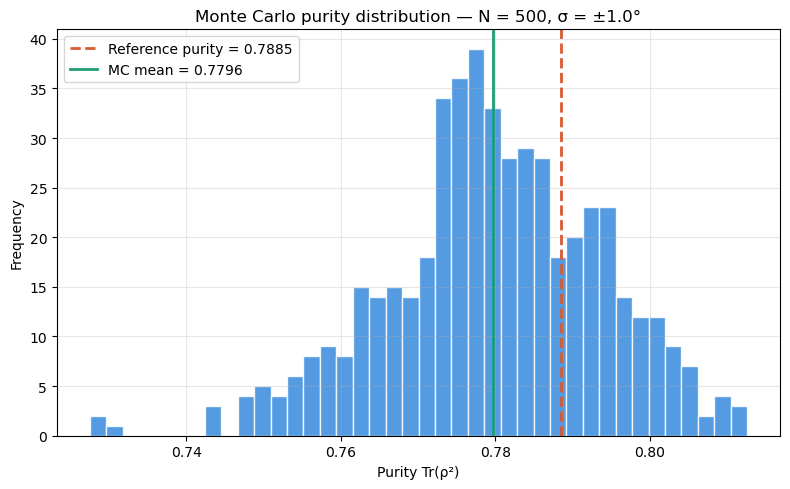

In [11]:
# ----------------------------------------------------------------------------
# 1. CONFIGURACIÓN DEL MONTE CARLO
# ----------------------------------------------------------------------------
N_ITER       = 500         # number of Monte Carlo iterations
SIGMA_DEG    = 1.0         # angular uncertainty per waveplate/polarizer (degrees)
rng = np.random.default_rng(42)

rho_ref = rho_mle.copy() 
purity_ref = np.real(np.trace(rho_ref @ rho_ref))

states = ['V', 'H', 'D', 'A', 'R', 'L']
twobits_states = [a + b for a in states for b in states]

# Lab states used in the experiment, with the waveplate setting that selects each one.
# Convention: the polarizer passes the lab-V state, which in code space is [1, 0]^T.
# Each entry: (waveplate_type, nominal_angle_deg)
LAB_STATES = {
    'V': ('NONE',  0.0),  'H': ('HWP',  45.0),
    'D': ('HWP',  22.5),  'A': ('HWP', -22.5),
    'R': ('QWP', -45.0),  'L': ('QWP',  45.0),
}

# ----------------------------------------------------------------------------
# 2. PHYSICAL FUNCTIONS (JONES MATRICES WITH ANGULAR ERROR)
# ----------------------------------------------------------------------------
def P_HWP_T(theta_degrees):
    th = np.radians(theta_degrees)
    return np.array([[np.cos(2*th), np.sin(2*th)], [np.sin(2*th), -np.cos(2*th)]], dtype=complex)

def P_QWP_T(theta_degrees):
    th = np.radians(theta_degrees)
    return np.array([
        [np.cos(th)**2 - 1j*np.sin(th)**2,     (1+1j)*np.sin(th)*np.cos(th)],
        [(1+1j)*np.sin(th)*np.cos(th),         np.sin(th)**2 - 1j*np.cos(th)**2]
    ], dtype=complex)

def polarizer_state(delta_pol_deg):
    th = np.radians(delta_pol_deg)
    return np.array([[np.cos(th)], [np.sin(th)]], dtype=complex)

def single_arm_projector(label, delta_wp_deg=0.0, delta_pol_deg=0.0):
    wp_type, theta_nom = LAB_STATES[label]
    
    if wp_type == 'NONE':
        U = np.eye(2, dtype=complex)
    elif wp_type == 'HWP':
        U = P_HWP_T(theta_nom + delta_wp_deg)
    elif wp_type == 'QWP':
        U = P_QWP_T(theta_nom + delta_wp_deg)
        
    p_state = polarizer_state(delta_pol_deg)
    measured_state = U.conj().T @ p_state
    return measured_state @ measured_state.conj().T

def joint_projector(label_A, label_B, d_wp_A=0.0, d_wp_B=0.0, d_pol_A=0.0, d_pol_B=0.0):
    Proj_A = single_arm_projector(label_A, d_wp_A, d_pol_A)
    Proj_B = single_arm_projector(label_B, d_wp_B, d_pol_B)
    return np.kron(Proj_A, Proj_B)

# Perfect theoretical projectors (that the computer assumes)
PROJECTORS_NOMINAL = [joint_projector(i[0], i[1]) for i in twobits_states]

# ----------------------------------------------------------------------------
# 6. MONTE CARLO LOOP
# ----------------------------------------------------------------------------
purity_samples = np.zeros(N_ITER)
eigvals_samples = np.zeros((N_ITER, 4))
rho_samples = np.zeros((N_ITER, 4, 4), dtype=complex) 

print(f"\nRunning {N_ITER} Monte Carlo iterations (σ = ±{SIGMA_DEG}°)...")

for i in tqdm(range(N_ITER)):
    # --- Polarizer errors: FIXED for the 36 measurements ---
    d_pol_A = rng.normal(0.0, SIGMA_DEG)
    d_pol_B = rng.normal(0.0, SIGMA_DEG)

    # --- Build the 36 "real" projectors and simulate counts ---
    n_counts_sim = np.zeros(36)
    
    for k, joint in enumerate(twobits_states):
        wp_type_A, _ = LAB_STATES[joint[0]]
        wp_type_B, _ = LAB_STATES[joint[1]]
        
        # Waveplate errors: INDEPENDENT for each measurement, only if waveplate present
        d_wp_A = rng.normal(0.0, SIGMA_DEG) if wp_type_A != 'NONE' else 0.0
        d_wp_B = rng.normal(0.0, SIGMA_DEG) if wp_type_B != 'NONE' else 0.0
        
        # Build the "real" projector with all the errors applied       
        Proj_real = joint_projector(joint[0], joint[1], d_wp_A, d_wp_B, d_pol_A, d_pol_B)
        
        # Expected count under the reference state and the REAL projector
        mu_k = max(0.0, N_total * np.real(np.trace(rho_ref @ Proj_real)))
        n_counts_sim[k] = rng.poisson(mu_k) # add Poisson noise (shot noise)
        
    # --- Reconstruct ρ assuming NOMINAL projectors (the lab does not know δ) ---
    opt_result = minimize( # returns the coordinates of the lowest point of a mathematical topology [f(x)]
        mle_cost_function,  
        t_initial, # variable values
        args=(n_counts_sim, PROJECTORS_NOMINAL, N_total), # fixed values
        method='L-BFGS-B', # Numerical Algorithm
        options={'maxiter': 5000, 'disp': False} # Boundary Conditions (maxiter=steps)
    )
    
    t_opt = opt_result.x
    T_opt = np.zeros((4, 4), dtype=complex)
    T_opt[0,0] = t_opt[0]; T_opt[1,1] = t_opt[1]; T_opt[2,2] = t_opt[2]; T_opt[3,3] = t_opt[3]
    T_opt[1,0] = t_opt[4]+1j*t_opt[5]; T_opt[2,1] = t_opt[6]+1j*t_opt[7]; T_opt[3,2] = t_opt[8]+1j*t_opt[9]
    T_opt[2,0] = t_opt[10]+1j*t_opt[11]; T_opt[3,1] = t_opt[12]+1j*t_opt[13]; T_opt[3,0] = t_opt[14]+1j*t_opt[15]
    
    rho_i = (T_opt.conj().T @ T_opt) / np.trace(T_opt.conj().T @ T_opt)
    
    #  Record the results
    purity_samples[i] = np.real(np.trace(rho_i @ rho_i))
    eigvals_samples[i] = np.sort(np.real(np.linalg.eigvalsh(rho_i)))[::-1]
    rho_samples[i] = rho_i
    
# ----------------------------------------------------------------------------
# 7. STATISTICS AND OUTPUT
# ----------------------------------------------------------------------------
print("\n" + "=" * 70)
print(" MONTE CARLO RESULTS (Angular errors ±1°)")
print("=" * 70)

# Purity
p_mean   = purity_samples.mean()
p_std    = purity_samples.std(ddof=1) # N_total - 1 (499).
p_lo, p_hi = np.percentile(purity_samples, [2.5, 97.5])
p_bias   = p_mean - purity_ref

print(f"\nReference purity:                    {purity_ref:.4f}")
print(f"Mean reconstructed purity:           {p_mean:.4f} ± {p_std:.4f}")
print(f"95% confidence interval:             [{p_lo:.4f}, {p_hi:.4f}]")
print(f"Systematic bias (mean − reference):  {p_bias:+.4f}")

# Eigenvalues
print("\nMean eigenvalues:")
ev_mean = eigvals_samples.mean(axis=0)
ev_std  = eigvals_samples.std(axis=0, ddof=1)
for i in range(4):
    print(f"  λ_{i+1} = {ev_mean[i]:.4f} ± {ev_std[i]:.4f}")

# Density matrix: ref, mean and std per element
print("\nReference Matrix ρ:")
print(np.round(rho_ref, 4))
print("\nMean reconstructed ρ (real part):")
print(np.round(rho_samples.mean(axis=0).real, 4))
print("\nStd of ρ (real part):")
print(np.round(rho_samples.real.std(axis=0, ddof=1), 4))
print("\nMean reconstructed ρ (imag part):")
print(np.round(rho_samples.mean(axis=0).imag, 4))
print("\nStd of ρ (imag part):")
print(np.round(rho_samples.imag.std(axis=0, ddof=1), 4))


# ----------------------------------------------------------------------------
# 8. HISTOGRAM OF PURITY
# ----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(purity_samples, bins=40, color='#378ADD', edgecolor='white', alpha=0.85)
ax.axvline(purity_ref, color='#D85A30', linestyle='--', linewidth=2,
           label=f'Reference purity = {purity_ref:.4f}')
ax.axvline(p_mean, color='#1D9E75', linestyle='-', linewidth=2,
           label=f'MC mean = {p_mean:.4f}')
ax.set_xlabel('Purity Tr(ρ²)')
ax.set_ylabel('Frequency')
ax.set_title(f'Monte Carlo purity distribution — N = {N_ITER}, σ = ±{SIGMA_DEG}°')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
fig.savefig('mc_purity_histogram.pdf', dpi=180, bbox_inches='tight')

### # ENTANGLEMENT METRICS — QST 4

 ENTANGLEMENT METRICS — QST 4
 CLOSEST PURE STATE

  Maximum fidelity to any pure state: 0.8812
  (= dominant eigenvalue of rho_mle)

  Dominant eigenvector in basis {|HH>, |HV>, |VH>, |VV>}:
    |HH>:  -0.5316 -0.0000i  (prob = 0.2826)
    |HV>:  +0.4292 +0.2496i  (prob = 0.2466)
    |VH>:  +0.1712 +0.4760i  (prob = 0.2559)
    |VV>:  -0.3618 +0.2899i  (prob = 0.2149)

── Partial trace (photon A) ──────────────────────────────────────
  ρ_A =
[[ 0.519 +0.j     -0.1271+0.0615j]
 [-0.1271-0.0615j  0.481 +0.j    ]]
  Purity of ρ_A:              0.5406

── Von Neumann entropy ───────────────────────────────────────────
  S(ρ_A) =                    0.9406 bits
  (max = 1 bit for Bell state, 0 for separable state)

── Concurrence (Wootters 1998) ───────────────────────────────────
  C =                         0.7356
  (range [0,1]; 1 = maximally entangled)

── Entanglement of formation ─────────────────────────────────────
  E_F =                       0.6374 ebits
  (min entanglement con

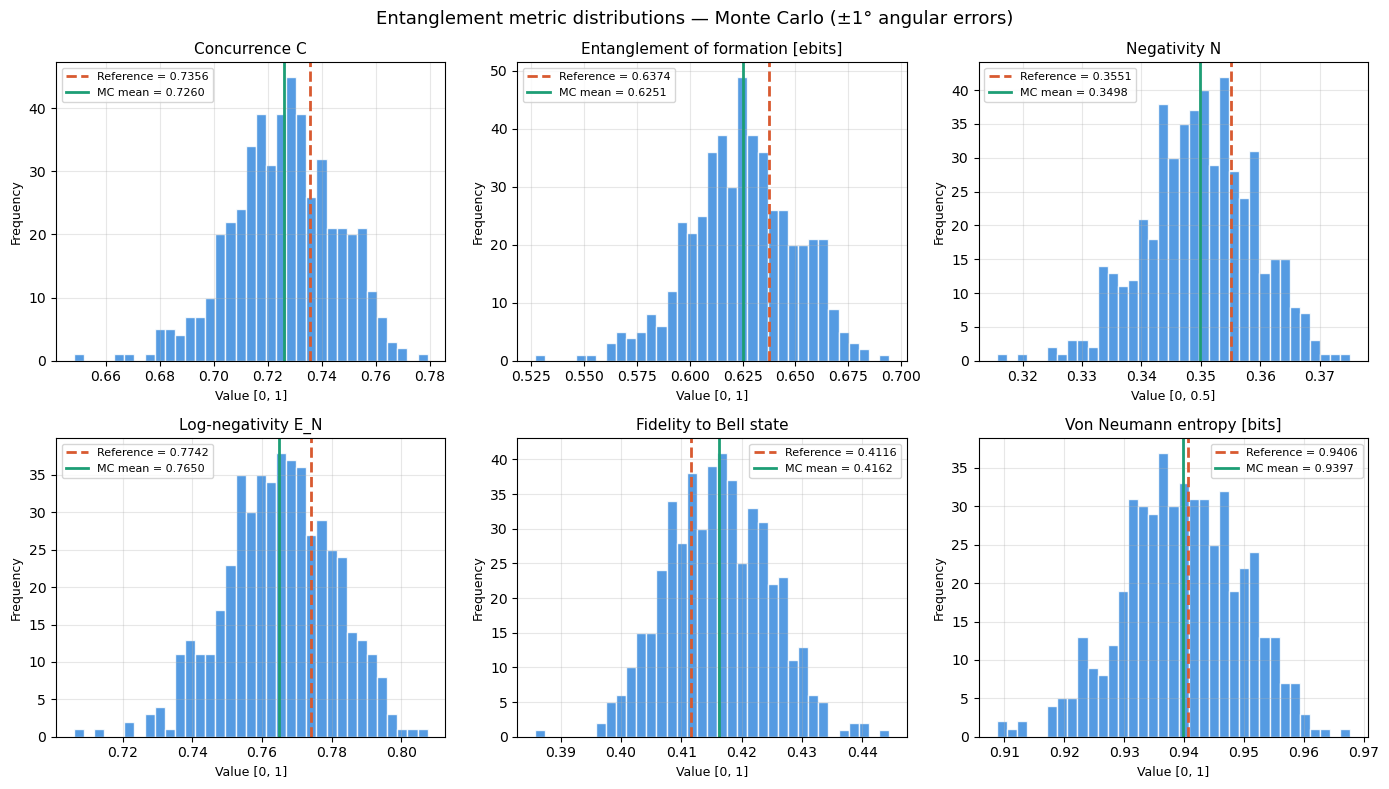

In [13]:
# Metrics computed:
#   1. Partial trace ρ_A and its purity
#   2. Von Neumann entropy S(ρ_A)
#   3. Concurrence C (Wootters 1998)
#   4. Entanglement of formation E_F
#   5. Negativity N and log-negativity E_N (Peres-Horodecki)
#   6. Fidelity to closest Bell state F
#   7. Werner state fit parameter p
# ============================================================================

from scipy.linalg import sqrtm

# ============================================================================
# METRIC FUNCTIONS
# ============================================================================

# ----------------------------------------------------------------------------
# 1. PARTIAL TRACE over photon B → 2×2 matrix of photon A
# ----------------------------------------------------------------------------
# Base order: |HH>, |HV>, |VH>, |VV>  →  indices 1,2,3,4
# Photon B=H: positions 1,3  |  Photon B=V: positions 2,4
# ρ_A[i,j] = ρ[i,j] + ρ[i+1,j+1]  with stride 2 (see derivation in notes)

def partial_trace_B(rho):
    """Trace out photon B from a 4×4 two-qubit density matrix.
    Returns the 2×2 reduced density matrix of photon A.
    Base: {|HH>, |HV>, |VH>, |VV>} — photon A first, photon B second.
    """
    rho_A = np.zeros((2, 2), dtype=complex)
    # Sum over B=H (positions 0,2) and B=V (positions 1,3)
    rho_A[0, 0] = rho[0, 0] + rho[1, 1]   # <HH|ρ|HH> + <HV|ρ|HV>
    rho_A[0, 1] = rho[0, 2] + rho[1, 3]   # <HH|ρ|VH> + <HV|ρ|VV>
    rho_A[1, 0] = rho[2, 0] + rho[3, 1]   # <VH|ρ|HH> + <VV|ρ|HV>
    rho_A[1, 1] = rho[2, 2] + rho[3, 3]   # <VH|ρ|VH> + <VV|ρ|VV>
    return rho_A


# ----------------------------------------------------------------------------
# 2. VON NEUMANN ENTROPY of a 2×2 matrix
# ----------------------------------------------------------------------------
def von_neumann_entropy(rho_2x2):
    """S(ρ) = -Σ λᵢ log₂(λᵢ)  with the convention 0·log(0) = 0."""
    eigvals = np.real(np.linalg.eigvalsh(rho_2x2))
    eigvals = np.clip(eigvals, 1e-15, 1.0)   # numerical safety (Ensure that all eigenvalues are in the range[1e-15, 1.0])
    return float(-np.sum(eigvals * np.log2(eigvals)))


# ----------------------------------------------------------------------------
# 3. CONCURRENCE (Wootters 1998)
# ----------------------------------------------------------------------------
def concurrence(rho):
    """C(ρ) = max(0, λ₁ - λ₂ - λ₃ - λ₄)
    where λᵢ are eigenvalues in decreasing order of
    R = sqrt(sqrt(ρ) · ρ̃ · sqrt(ρ)),  ρ̃ = (σy⊗σy) ρ* (σy⊗σy).
    """
    sigma_yy = np.kron(sigma_2, sigma_2)

    rho_tilde = sigma_yy @ rho.conj() @ sigma_yy

    sqrt_rho = sqrtm(rho)
    R = sqrtm(sqrt_rho @ rho_tilde @ sqrt_rho)

    eigvals = np.sort(np.real(np.linalg.eigvalsh(R)))[::-1]
    return float(max(0.0, eigvals[0] - eigvals[1] - eigvals[2] - eigvals[3]))


# ----------------------------------------------------------------------------
# 4. ENTANGLEMENT OF FORMATION
# ----------------------------------------------------------------------------
def entanglement_of_formation(C):
    """E_F = h((1 + sqrt(1-C²)) / 2)  where h is the binary entropy.
    Wootters (1998): minimum entanglement (in ebits) needed to form the state.
    """
    if C <= 0.0:
        return 0.0
    if C >= 1.0:
        return 1.0
    mu = (1.0 + np.sqrt(1.0 - C**2)) / 2.0
    mu = np.clip(mu, 1e-15, 1.0 - 1e-15)  # numerical safety (Ensure that all eigenvalues are in the range[1e-15, 1.0 - 1e-15])
    return float(-mu * np.log2(mu) - (1 - mu) * np.log2(1 - mu))


# ----------------------------------------------------------------------------
# 5. NEGATIVITY AND LOG-NEGATIVITY (Peres-Horodecki criterion)
# ----------------------------------------------------------------------------
def partial_transpose_B(rho):
    """Partial transpose of ρ over photon B.
    Transposes each 2×2 block of the block-matrix structure.
    """
    rho_TB = rho.copy()
    # Swap off-diagonal elements within each block
    # Block structure (A=H,B=H), (A=H,B=V), (A=V,B=H), (A=V,B=V)
    # Transposing B indices: swap positions (0,1)↔(1,0) within each block
    rho_TB[0, 1], rho_TB[1, 0] = rho[1, 0], rho[0, 1]   # top-left block
    rho_TB[0, 3], rho_TB[1, 2] = rho[1, 2], rho[0, 3]   # top-right block
    rho_TB[2, 1], rho_TB[3, 0] = rho[3, 0], rho[2, 1]   # bottom-left block
    rho_TB[2, 3], rho_TB[3, 2] = rho[3, 2], rho[2, 3]   # bottom-right block
    return rho_TB


def negativity(rho):
    """N(ρ) = sum of absolute values of negative eigenvalues of ρ^{T_B}.
    Equivalent to (||ρ^{T_B}||₁ - 1) / 2.
    """
    rho_TB = partial_transpose_B(rho)
    eigvals = np.real(np.linalg.eigvalsh(rho_TB))
    return float(np.sum(np.abs(eigvals[eigvals < 0])))


def log_negativity(rho):
    """E_N = log₂(2N + 1) = log₂(||ρ^{T_B}||₁)."""
    rho_TB = partial_transpose_B(rho)
    trace_norm = np.sum(np.abs(np.real(np.linalg.eigvalsh(rho_TB))))
    return float(np.log2(trace_norm))


# ----------------------------------------------------------------------------
# 6. FIDELITY TO CLOSEST BELL STATE
# ----------------------------------------------------------------------------
# Bell states in the basis {|HH>, |HV>, |VH>, |VV>}
BELL_STATES = {
    'Phi+': np.array([1, 0, 0, 1], dtype=complex) / np.sqrt(2),
    'Phi-': np.array([1, 0, 0, -1], dtype=complex) / np.sqrt(2),
    'Psi+': np.array([0, 1, 1, 0], dtype=complex) / np.sqrt(2),
    'Psi-': np.array([0, 1, -1, 0], dtype=complex) / np.sqrt(2),
}

def fidelity_closest_bell(rho):
    """F = max over Bell states of <Ψ_B|ρ|Ψ_B>.
    Returns (fidelity, name_of_closest_bell_state).
    """
    best_F = 0.0
    best_name = ''
    for name, psi in BELL_STATES.items():
        F = float(np.real(psi.conj() @ rho @ psi))
        if F > best_F:
            best_F = F
            best_name = name
    return best_F, best_name


# ----------------------------------------------------------------------------
# 7. WERNER STATE FIT
# ----------------------------------------------------------------------------
def werner_p_from_fidelity(F):
    """Extract Werner parameter p from fidelity to closest Bell state.
    For a Werner state: F = (1 + 3p) / 4  →  p = (4F - 1) / 3.
    """
    return float((4 * F - 1) / 3)


def werner_metrics(p):
    """Analytical metrics of a Werner state as a function of p."""
    purity  = (1 + 3 * p**2) / 4
    C       = max(0.0, (3 * p - 1) / 2)
    F       = (1 + 3 * p) / 4
    N       = max(0.0, (3 * p - 1) / 4)
    E_N     = np.log2(2 * N + 1) if N > 0 else 0.0
    E_F     = entanglement_of_formation(C)
    return {'purity': purity, 'C': C, 'F': F,
            'negativity': N, 'log_neg': E_N, 'E_F': E_F}


# ============================================================================
# COMPUTE ALL METRICS FOR rho_mle
# ============================================================================
print("=" * 70)
print(" ENTANGLEMENT METRICS — QST 4")
print("=" * 70)

rho = rho_mle.copy()

# Dominant eigenvector — closest pure state to rho_mle
eigvals_rho, eigvecs_rho = np.linalg.eigh(rho_mle)
dominant_state = eigvecs_rho[:, -1]   # largest eigenvalue is last
F_max_pure = float(eigvals_rho[-1])

print("=" * 70)
print(" CLOSEST PURE STATE")
print("=" * 70)
print(f"\n  Maximum fidelity to any pure state: {F_max_pure:.4f}")
print(f"  (= dominant eigenvalue of rho_mle)")
print(f"\n  Dominant eigenvector in basis {{|HH>, |HV>, |VH>, |VV>}}:")
labels = ['|HH>', '|HV>', '|VH>', '|VV>']
for i, label in enumerate(labels):
    coef = dominant_state[i]
    print(f"    {label}:  {coef.real:+.4f} {coef.imag:+.4f}i  "
          f"(prob = {abs(coef)**2:.4f})")

# 1. Partial trace and entropy
rho_A   = partial_trace_B(rho)
purity_A = float(np.real(np.trace(rho_A @ rho_A)))
S        = von_neumann_entropy(rho_A)

# 2. Concurrence and E_F
C   = concurrence(rho)
E_F = entanglement_of_formation(C)

# 3. Negativity
N   = negativity(rho)
E_N = log_negativity(rho)

# 4. Fidelity and Werner fit
F, bell_name = fidelity_closest_bell(rho) # Fidelity to closest Bell state (standard 4)
F_optimal = float(np.real(dominant_state.conj() @ rho @ dominant_state)) # Fidelity to optimal pure state (dominant eigenvector)
p_werner_std  = werner_p_from_fidelity(F)           # with standard Bell
p_werner_opt  = werner_p_from_fidelity(F_optimal)   # with optimal state
w_metrics_opt = werner_metrics(p_werner_opt)

print(f"\n── Partial trace (photon A) ──────────────────────────────────────")
print(f"  ρ_A =\n{np.round(rho_A, 4)}")
print(f"  Purity of ρ_A:              {purity_A:.4f}")

print(f"\n── Von Neumann entropy ───────────────────────────────────────────")
print(f"  S(ρ_A) =                    {S:.4f} bits")
print(f"  (max = 1 bit for Bell state, 0 for separable state)")

print(f"\n── Concurrence (Wootters 1998) ───────────────────────────────────")
print(f"  C =                         {C:.4f}")
print(f"  (range [0,1]; 1 = maximally entangled)")

print(f"\n── Entanglement of formation ─────────────────────────────────────")
print(f"  E_F =                       {E_F:.4f} ebits")
print(f"  (min entanglement content of the state)")

print(f"\n── Negativity (Peres-Horodecki) ──────────────────────────────────")
print(f"  Negativity N =              {N:.4f}  (range [0, 0.5])")
print(f"  Log-negativity E_N =        {E_N:.4f}  (range [0, 1])")

print(f"\n── Fidelity ──────────────────────────────────────────────────────")
print(f"  Closest standard Bell state:    |{bell_name}>  F = {F:.4f}")
print(f"  Closest pure state (optimal):   F = {F_optimal:.4f}")
print(f"  (F > 0.5 certifies entanglement)")

print(f"\n── Werner state fit ──────────────────────────────────────────────")
print(f"  Werner p (standard Bell state): {p_werner_std:.4f}  ← poor fit")
print(f"  Werner p (optimal pure state):  {p_werner_opt:.4f}  ← correct fit")
print(f"  Werner predictions from optimal p:")
for k, v in w_metrics_opt.items():
    print(f"    {k:<12} = {v:.4f}")


# ============================================================================
# UNCERTAINTY PROPAGATION FROM MONTE CARLO
# ============================================================================
print(f"\n{'=' * 70}")
print(" METRIC UNCERTAINTIES FROM MONTE CARLO (±1° angular errors)")
print("=" * 70)

# Compute all metrics for each MC sample
N_ITER = rho_samples.shape[0]

mc_purity_A = np.zeros(N_ITER)  
mc_S    = np.zeros(N_ITER)
mc_C    = np.zeros(N_ITER)
mc_EF   = np.zeros(N_ITER)
mc_N    = np.zeros(N_ITER)
mc_EN   = np.zeros(N_ITER)
mc_F    = np.zeros(N_ITER)
mc_p    = np.zeros(N_ITER)

print(f"Computing metrics for {N_ITER} Monte Carlo samples...")

for i in range(N_ITER):
    rho_i   = rho_samples[i]
    rho_A_i = partial_trace_B(rho_i)
    
    mc_purity_A[i] = np.real(np.trace(rho_A_i @ rho_A_i))   
    mc_S[i]  = von_neumann_entropy(rho_A_i)
    C_i      = concurrence(rho_i)
    mc_C[i]  = C_i
    mc_EF[i] = entanglement_of_formation(C_i)
    mc_N[i]  = negativity(rho_i)
    mc_EN[i] = log_negativity(rho_i)
    F_i, _   = fidelity_closest_bell(rho_i)
    mc_F[i]  = F_i
    mc_p[i]  = werner_p_from_fidelity(F_i)

def report(name, ref_val, samples, unit=''):
    mean = samples.mean()
    std  = samples.std(ddof=1)
    lo, hi = np.percentile(samples, [2.5, 97.5])
    bias = mean - ref_val
    print(f"\n  {name}")
    print(f"    Reference:    {ref_val:.4f} {unit}")
    print(f"    MC mean:      {mean:.4f} ± {std:.4f} {unit}")
    print(f"    95% CI:       [{lo:.4f}, {hi:.4f}]")
    print(f"    Bias:         {bias:+.4f}")

report("Von Neumann entropy S(ρ_A)", S,   mc_S,  "bits")
report("Concurrence C",              C,   mc_C)
report("Entanglement of formation",  E_F, mc_EF, "ebits")
report("Negativity N",               N,   mc_N)
report("Log-negativity E_N",         E_N, mc_EN)
report("Fidelity F",                 F,   mc_F)
report("Werner parameter p",         p_werner_opt, mc_p)


# ============================================================================
# SUMMARY TABLE
# ============================================================================
print(f"\n{'=' * 70}")
print(" SUMMARY TABLE")
print("=" * 70)
print(f"{'Metric':<30} {'Value':>10} {'± std':>10} {'95% CI':>13}")
print("-" * 70)

rows = [
    ("Purity Tr(ρ²)",          purity_ref,  purity_samples),
    ("Purity of ρ_A",          purity_A,    mc_purity_A),
    ("Von Neumann entropy [b]", S,           mc_S),
    ("Concurrence C",           C,           mc_C),
    ("Entanglement of form.",   E_F,        mc_EF),
    ("Negativity N",            N,           mc_N),
    ("Log-negativity E_N",      E_N,         mc_EN),
    ("Fidelity to Bell state",  F,           mc_F),
    ("Werner parameter p",      p_werner_opt,    mc_p),
]

for name, ref, samples in rows:
    if samples is not None:
        std  = samples.std(ddof=1)
        lo, hi = np.percentile(samples, [2.5, 97.5])
        print(f"  {name:<28} {ref:>10.4f} {std:>10.4f}   [{lo:.4f}, {hi:.4f}]")
    else:
        print(f"  {name:<28} {ref:>10.4f} {'—':>10}   {'—':>22}")


# ============================================================================
# VISUALIZATION — METRIC DISTRIBUTIONS FROM MONTE CARLO
# ============================================================================
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Entanglement metric distributions — Monte Carlo (±1° angular errors)',
             fontsize=13)

plot_data = [
    (mc_C,   C,   'Concurrence C',              '[0, 1]'),
    (mc_EF,  E_F, 'Entanglement of formation [ebits]','[0, 1]'),
    (mc_N,   N,   'Negativity N',               '[0, 0.5]'),
    (mc_EN,  E_N, 'Log-negativity E_N',         '[0, 1]'),
    (mc_F,   F,   'Fidelity to Bell state',     '[0, 1]'),
    (mc_S,   S,   'Von Neumann entropy [bits]', '[0, 1]'),
]

for ax, (samples, ref, title, rng_label) in zip(axes.flat, plot_data):
    ax.hist(samples, bins=35, color='#378ADD', edgecolor='white', alpha=0.85)
    ax.axvline(ref, color='#D85A30', linestyle='--', linewidth=2,
               label=f'Reference = {ref:.4f}')
    ax.axvline(samples.mean(), color='#1D9E75', linestyle='-', linewidth=2,
               label=f'MC mean = {samples.mean():.4f}')
    ax.set_title(title, fontsize=11)
    ax.set_xlabel(f'Value {rng_label}', fontsize=9)
    ax.set_ylabel('Frequency', fontsize=9)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
fig.savefig('metricas.png', dpi=180, bbox_inches='tight')

In [14]:
# Bell states in basis {|HH>, |HV>, |VH>, |VV>}
print("Decomposition of dominant eigenvector in Bell basis:")
print("=" * 55)
total_prob = 0
for name, bell in BELL_STATES.items():
    coef = np.dot(bell.conj(), dominant_state)
    prob = abs(coef)**2
    total_prob += prob
    print(f"  |{name}>:  coef = {coef.real:+.4f}{coef.imag:+.4f}i  "
          f"(prob = {prob:.4f})")
print(f"\n  Sum of probabilities: {total_prob:.4f}")
print(f"\n  Dominant eigenvector expressed as Bell combination:")
coeffs = {name: np.dot(bell.conj(), dominant_state) 
          for name, bell in BELL_STATES.items()}
print(f"  |ψ_opt> = ", end="")
for name, c in coeffs.items():
    print(f"({c.real:+.4f}{c.imag:+.4f}i)|{name}> ", end="")

Decomposition of dominant eigenvector in Bell basis:
  |Phi+>:  coef = -0.6318+0.2050i  (prob = 0.4411)
  |Phi->:  coef = -0.1201-0.2050i  (prob = 0.0564)
  |Psi+>:  coef = +0.4246+0.5131i  (prob = 0.4435)
  |Psi->:  coef = +0.1825-0.1601i  (prob = 0.0589)

  Sum of probabilities: 1.0000

  Dominant eigenvector expressed as Bell combination:
  |ψ_opt> = (-0.6318+0.2050i)|Phi+> (-0.1201-0.2050i)|Phi-> (+0.4246+0.5131i)|Psi+> (+0.1825-0.1601i)|Psi-> 

In [15]:
print("\n\nFULL STATE STRUCTURE")
print("=" * 55)

eigvals_sorted = eigvals_rho[::-1]
eigvecs_sorted = eigvecs_rho[:, ::-1]

for k in range(4):
    vec = eigvecs_sorted[:, k]
    lam = eigvals_sorted[k]
    
    if lam < 0.001:
        print(f"\nEigenvector {k+1}: λ = {lam:.4f} (negligible)")
        continue
    
    # Concurrence of this pure state
    a, b, c, d = vec
    C_k = 2 * abs(a*d - b*c)
    
    # Bell decomposition
    print(f"\nEigenvector {k+1}: λ = {lam:.4f}  "
          f"(contributes {lam*100:.1f}% of state)")
    print(f"  Concurrence: {C_k:.4f}")
    print(f"  Probabilities in HV basis:")
    labels = ['|HH>', '|HV>', '|VH>', '|VV>']
    for i, label in enumerate(labels):
        print(f"    {label}: {abs(vec[i])**2:.4f}")
    print(f"  Bell decomposition:")
    for name, bell in BELL_STATES.items():
        coef = np.dot(bell.conj(), vec)
        prob = abs(coef)**2
        if prob > 0.01:
            print(f"    |{name}>: prob = {prob:.4f}")

# Final summary
print("\n\nSUMMARY")
print("=" * 55)
print(f"ρ̂ = ", end="")
for k in range(4):
    lam = eigvals_sorted[k]
    if lam > 0.001:
        print(f"{lam:.3f}·|ψ{k+1}⟩⟨ψ{k+1}| + ", end="")
print("...")



FULL STATE STRUCTURE

Eigenvector 1: λ = 0.8812  (contributes 88.1% of state)
  Concurrence: 0.9326
  Probabilities in HV basis:
    |HH>: 0.2826
    |HV>: 0.2466
    |VH>: 0.2559
    |VV>: 0.2149
  Bell decomposition:
    |Phi+>: prob = 0.4411
    |Phi->: prob = 0.0564
    |Psi+>: prob = 0.4435
    |Psi->: prob = 0.0589

Eigenvector 2: λ = 0.1088  (contributes 10.9% of state)
  Concurrence: 0.7202
  Probabilities in HV basis:
    |HH>: 0.0665
    |HV>: 0.3660
    |VH>: 0.1340
    |VV>: 0.4335
  Bell decomposition:
    |Phi+>: prob = 0.2074
    |Phi->: prob = 0.2926
    |Psi+>: prob = 0.1433
    |Psi->: prob = 0.3567

Eigenvector 3: λ = 0.0100  (contributes 1.0% of state)
  Concurrence: 0.9529
  Probabilities in HV basis:
    |HH>: 0.1806
    |HV>: 0.3823
    |VH>: 0.3868
    |VV>: 0.0504
  Bell decomposition:
    |Phi+>: prob = 0.0352
    |Phi->: prob = 0.1958
    |Psi+>: prob = 0.3228
    |Psi->: prob = 0.4463

Eigenvector 4: λ = 0.0000 (negligible)


SUMMARY
ρ̂ = 0.881·|ψ1⟩⟨ψ1| + 